# O(n log2 n)

## 1. Import các thư viện

In [11]:
import numpy as np
import time
import matplotlib.pyplot as plt
import os
from utils import plot_execution_times, measure_algorithm_time

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Cài đặt thuật toán Merge Sort - Độ phức tạp O(n log n)

In [12]:
def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        L = arr[:mid]
        R = arr[mid:]

        merge_sort(L)
        merge_sort(R)

        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1

        while i < len(L):
            arr[k] = L[i]
            i += 1
            k += 1

        while j < len(R):
            arr[k] = R[j]
            j += 1
            k += 1

## 3. Đọc dữ liệu từ file npz

In [13]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

# Từ điển lưu trữ dữ liệu đã đọc: cấu trúc loaded_data['tên_dataset']['kích_thước']
loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            # Lưu mảng dữ liệu vào từ điển
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

In [14]:
print("Đang đo Merge Sort...")
results_n_logn = measure_algorithm_time(merge_sort, loaded_data, datasets, sizes)

Đang đo Merge Sort...


## 5. Biểu đồ trực quan

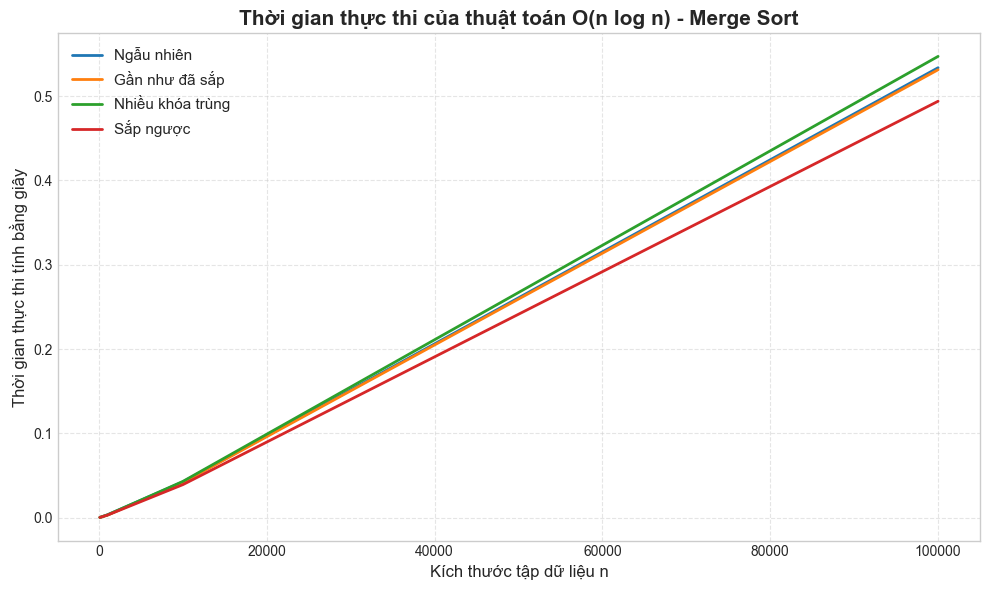

In [15]:
plot_execution_times(
    results_dict=results_n_logn, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n log n) - Merge Sort"
)